# Checkpoint 2 — Dynamic Programming
## FIAP | Professor: Andre Marques

---

 Integrantes

Felipe Bernardes de Almeida RM 564360
Guilherme Romero RM 564431

---


## Introdução

Este projeto modela redes metroviárias de três grandes cidades como **grafos ponderados não-direcionados**, aplicando técnicas de **programação dinâmica** para encontrar caminhos ótimos.

### Cidades analisadas
-  **São Paulo** — Metrô + CPTM | Tucuruvi → Capão Redondo
-  **Beijing** — Linhas 1, 2, 4 e 10 | Sihui East → Xizhimen
- **San Francisco** — BART | Dublin/Pleasanton → Daly City

### Objetivos
1. Encontrar o **menor caminho** com recursão + memoização (`lru_cache`)
2. Encontrar o **maior caminho simples** com backtracking
3. Aplicar **penalidades e bônus** por faixa de horário
4. Comparar desempenho **com e sem memoização** (tempo + memória)
5. Exibir **visualização interativa** com Folium


In [18]:
import time
import tracemalloc
import functools
import folium
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120


---
## Seção 1 — Modelagem dos Grafos

### Decisão de projeto: grafo não-direcionado

Optamos por um grafo **não-direcionado** pois sistemas metroviários permitem tráfego nos dois sentidos com o mesmo custo por trecho. Cada aresta aparece nas listas de adjacência de **ambos** os nós que ela conecta.

- **Nó** = estação
- **Aresta** = trecho entre estações
- **Peso** = tempo estimado de deslocamento (minutos)

> ⚠️ Estações marcadas com `★` são pontos de integração entre linhas diferentes.


In [19]:
# ─── São Paulo ─── Metrô + CPTM
# Linha 1 (Azul): Tucuruvi → Luz → Sé
# Linha 3 (Vermelha): Sé (integração )
# Linha 2 (Verde): Ana Rosa (integração )
# Linha 5 (Lilás): Ana Rosa → Capão Redondo

grafo_sp = {
    "Tucuruvi":           [("Parada Inglesa", 3)],
    "Parada Inglesa":     [("Tucuruvi", 3), ("Jardim São Paulo", 2)],
    "Jardim São Paulo":   [("Parada Inglesa", 2), ("Santana", 3)],
    "Santana":            [("Jardim São Paulo", 3), ("Carandiru", 2)],
    "Carandiru":          [("Santana", 2), ("Portuguesa-Tietê", 2)],
    "Portuguesa-Tietê":   [("Carandiru", 2), ("Armênia", 2)],
    "Armênia":            [("Portuguesa-Tietê", 2), ("Tiradentes", 2)],
    "Tiradentes":         [("Armênia", 2), ("Luz", 3)],
    "Luz":                [("Tiradentes", 3), ("São Bento", 2), ("Sé", 4)],
    "São Bento":          [("Luz", 2), ("Sé", 2)],
    "Sé":                 [("São Bento", 2), ("Luz", 4), ("Ana Rosa", 5)],
    "Ana Rosa":           [("Sé", 5), ("Santa Cruz", 4)],
    "Santa Cruz":         [("Ana Rosa", 4), ("Hospital São Paulo", 3)],
    "Hospital São Paulo": [("Santa Cruz", 3), ("Santo Amaro", 4)],
    "Santo Amaro":        [("Hospital São Paulo", 4), ("Capão Redondo", 6)],
    "Capão Redondo":      [],
}

estacoes_integracao_sp = {"Luz", "Sé", "Ana Rosa", "Santo Amaro"}

coords_sp = {
    "Tucuruvi":           (-23.4753, -46.6145),
    "Parada Inglesa":     (-23.4884, -46.6201),
    "Jardim São Paulo":   (-23.5004, -46.6250),
    "Santana":            (-23.5076, -46.6282),
    "Carandiru":          (-23.5147, -46.6269),
    "Portuguesa-Tietê":   (-23.5205, -46.6215),
    "Armênia":            (-23.5272, -46.6272),
    "Tiradentes":         (-23.5332, -46.6358),
    "Luz":                (-23.5355, -46.6334),
    "São Bento":          (-23.5411, -46.6352),
    "Sé":                 (-23.5503, -46.6339),
    "Ana Rosa":           (-23.5753, -46.6452),
    "Santa Cruz":         (-23.5905, -46.6551),
    "Hospital São Paulo": (-23.5997, -46.6612),
    "Santo Amaro":        (-23.6502, -46.7021),
    "Capão Redondo":      (-23.6699, -46.7406),
}

print(f"São Paulo: {len(grafo_sp)} estações")
print(f"Estações de integração: {estacoes_integracao_sp}")


São Paulo: 16 estações
Estações de integração: {'Ana Rosa', 'Luz', 'Santo Amaro', 'Sé'}


In [20]:
# ─── Beijing ─── Linhas 1, 2, 4 e 10
# Linha 1 (East-West): Sihui East →  → Fuxingmen → Xizhimen
# Linha 2 (loop norte): inclui Chaoyangmen, Dongsi, Guloudajie, Jishuitan
# Guomao  e Jianguomen  — estações de integração entre Linha 1 e Linha 10

grafo_beijing = {

    "Sihui East":   [("Sihui", 2), ("Guomao", 5)],
    "Sihui":        [("Sihui East", 2), ("Dawanglu", 2)],
    "Dawanglu":     [("Sihui", 2), ("Guomao", 2)],
    "Guomao":       [("Dawanglu", 2), ("Sihui East", 5), ("Jianguomen", 3), ("Yonganli", 2)],
    "Jianguomen":   [("Guomao", 3), ("Dongdan", 2), ("Chaoyangmen", 2)],
    "Dongdan":      [("Jianguomen", 2), ("Xidan", 4)],
    "Xidan":        [("Dongdan", 4), ("Fuxingmen", 3), ("Pinganli", 2)],
    "Fuxingmen":    [("Xidan", 3), ("Xizhimen", 4)],
    "Xizhimen":     [],

    "Yonganli":     [("Guomao", 2), ("Jianguomen", 3)],
    "Chaoyangmen":  [("Jianguomen", 2), ("Dongsi", 2)],
    "Dongsi":       [("Chaoyangmen", 2), ("Guloudajie", 3)],
    "Pinganli":     [("Xidan", 2), ("Xizhimen", 3)],
    "Guloudajie":   [("Dongsi", 3), ("Jishuitan", 2), ("Xizhimen", 3)],
    "Jishuitan":    [("Guloudajie", 2), ("Xizhimen", 2)],
}

estacoes_integracao_bj = {"Guomao", "Jianguomen", "Xidan"}

coords_beijing = {
    "Sihui East":  (39.9042, 116.5002),
    "Sihui":       (39.9042, 116.4893),
    "Dawanglu":    (39.9042, 116.4760),
    "Guomao":      (39.9042, 116.4608),
    "Jianguomen":  (39.9042, 116.4399),
    "Dongdan":     (39.9154, 116.4186),
    "Xidan":       (39.9154, 116.3661),
    "Fuxingmen":   (39.9154, 116.3484),
    "Xizhimen":    (39.9432, 116.3483),
    "Yonganli":    (39.9018, 116.4608),
    "Chaoyangmen": (39.9233, 116.4399),
    "Dongsi":      (39.9319, 116.4191),
    "Pinganli":    (39.9319, 116.3661),
    "Guloudajie":  (39.9467, 116.4078),
    "Jishuitan":   (39.9467, 116.3659),
}

print(f"Beijing: {len(grafo_beijing)} estações")
print(f"Estações de integração: {estacoes_integracao_bj}")


Beijing: 15 estações
Estações de integração: {'Xidan', 'Guomao', 'Jianguomen'}


In [21]:
# ─── San Francisco ─── BART
# Linha Azul: Dublin/Pleasanton → Bay Fair → Fruitvale → Oakland → SF → Daly City
# Linha Amarela: similar mas via San Leandro
# Bay Fair  — ponto de bifurcação (Blue/Yellow)

grafo_sf = {
    "Dublin/Pleasanton": [("West Dublin", 4)],
    "West Dublin":       [("Dublin/Pleasanton", 4), ("Castro Valley", 5)],
    "Castro Valley":     [("West Dublin", 5), ("Bay Fair", 4)],
    "Bay Fair":          [("Castro Valley", 4), ("San Leandro", 3), ("Coliseum", 4)],
    "San Leandro":       [("Bay Fair", 3), ("Coliseum", 3)],
    "Coliseum":          [("San Leandro", 3), ("Fruitvale", 3), ("Bay Fair", 4)],
    "Fruitvale":         [("Coliseum", 3), ("Lake Merritt", 3)],
    "Lake Merritt":      [("Fruitvale", 3), ("West Oakland", 4)],
    "West Oakland":      [("Lake Merritt", 4), ("Embarcadero", 5)],
    "Embarcadero":       [("West Oakland", 5), ("Montgomery", 2)],
    "Montgomery":        [("Embarcadero", 2), ("Powell", 2)],
    "Powell":            [("Montgomery", 2), ("Civic Center", 2)],
    "Civic Center":      [("Powell", 2), ("16th St", 3)],
    "16th St":           [("Civic Center", 3), ("24th St", 2)],
    "24th St":           [("16th St", 2), ("Daly City", 4)],
    "Daly City":         [],
}

estacoes_integracao_sf = {"Bay Fair", "Coliseum"}

coords_sf = {
    "Dublin/Pleasanton": (37.7016, -121.9000),
    "West Dublin":       (37.6995, -121.9281),
    "Castro Valley":     (37.6908, -122.0759),
    "Bay Fair":          (37.6970, -122.1268),
    "San Leandro":       (37.7022, -122.1610),
    "Coliseum":          (37.7540, -122.1977),
    "Fruitvale":         (37.7749, -122.2244),
    "Lake Merritt":      (37.7977, -122.2651),
    "West Oakland":      (37.8047, -122.2950),
    "Embarcadero":       (37.7929, -122.3967),
    "Montgomery":        (37.7893, -122.4018),
    "Powell":            (37.7840, -122.4077),
    "Civic Center":      (37.7796, -122.4146),
    "16th St":           (37.7651, -122.4195),
    "24th St":           (37.7523, -122.4183),
    "Daly City":         (37.7060, -122.4695),
}

print(f"San Francisco: {len(grafo_sf)} estações")
print(f"Estações de integração: {estacoes_integracao_sf}")


San Francisco: 16 estações
Estações de integração: {'Bay Fair', 'Coliseum'}


---
## Seção 2 — Fatores de Horário

O peso de cada aresta é multiplicado por um fator antes da busca:

| Faixa | Fator | Motivo |
|---|---|---|
| 5h – 7h | × 0.6 | Bônus — metrô vazio, embarque rápido |
| 7h – 9h | × 1.5 | Penalidade moderada — pico da manhã |
| 9h – 17h | × 1.0 | Normal — sem penalidade |
| 17h – 20h | × 2.0 | Penalidade máxima — pico da tarde |
| Demais | × 1.0 | Padrão |


In [22]:
def fator_horario(hora: int) -> float:
    if 5 <= hora < 7:
        return 0.6
    elif 7 <= hora < 9:
        return 1.5
    elif 9 <= hora < 17:
        return 1.0
    elif 17 <= hora < 20:
        return 2.0
    return 1.0

try:
    hora_partida = int(input("Informe o horário de partida (0-23): "))
    if not (0 <= hora_partida <= 23):
        raise ValueError("Fora do intervalo")
except Exception:
    hora_partida = 18
    print(f"Usando horário padrão: {hora_partida}h  |  (edite a variável hora_partida para testar outros horários)")

fator_atual = fator_horario(hora_partida)
print(f"\nHorário de partida: {hora_partida}h | Fator aplicado: {fator_atual}x")
print(f"Faixa: {'Bônus (madrugada)' if fator_atual < 1 else 'Pico alto' if fator_atual == 2.0 else 'Pico moderado' if fator_atual == 1.5 else 'Normal'}")


Informe o horário de partida (0-23): 22

Horário de partida: 22h | Fator aplicado: 1.0x
Faixa: Normal


---
## Seção 3 — Algoritmos

### 3.1 Menor Caminho — Recursão com Memoização

Usamos `functools.lru_cache` para armazenar subproblemas já resolvidos.
O estado é definido por `(origem, destino, hora, visitados)` — `visitados` é um `frozenset` (imutável, hashável) para compatibilidade com o cache.

A função retorna uma **tupla `(custo, caminho)`**, onde `caminho` é a sequência de estações.


In [23]:
def criar_menor_caminho(grafo: dict):
    """
    Fábrica que cria uma função de menor caminho com memoização (lru_cache)
    para o grafo informado.
    Retorna (custo_total, caminho_como_tupla).
    """
    @functools.lru_cache(maxsize=None)
    def menor_caminho(origem: str, destino: str, hora: int,
                      visitados: frozenset = frozenset()):
        if origem == destino:
            return (0.0, (origem,))

        melhor_custo = float('inf')
        melhor_path: tuple = ()
        fator = fator_horario(hora)

        for vizinho, peso in grafo.get(origem, []):
            if vizinho not in visitados:
                custo_v, path_v = menor_caminho(
                    vizinho, destino, hora, visitados | {origem}
                )
                if custo_v != float('inf'):
                    total = fator * peso + custo_v
                    if total < melhor_custo:
                        melhor_custo = total
                        melhor_path = (origem,) + path_v

        return (melhor_custo, melhor_path)

    return menor_caminho


### 3.2 Menor Caminho — Sem Memoização (para comparação de desempenho)

Mesma lógica recursiva, **sem cache**. Serve exclusivamente para medir o impacto da memoização.


In [24]:
def menor_caminho_sem_cache(grafo: dict, origem: str, destino: str,
                             hora: int, visitados: frozenset = frozenset()):
    """
    Versão sem cache — estruturalmente idêntica à versão memoizada.
    Retorna (custo_total, caminho_como_tupla).
    """
    if origem == destino:
        return (0.0, (origem,))

    melhor_custo = float('inf')
    melhor_path: tuple = ()
    fator = fator_horario(hora)

    for vizinho, peso in grafo.get(origem, []):
        if vizinho not in visitados:
            custo_v, path_v = menor_caminho_sem_cache(
                grafo, vizinho, destino, hora, visitados | {origem}
            )
            if custo_v != float('inf'):
                total = fator * peso + custo_v
                if total < melhor_custo:
                    melhor_custo = total
                    melhor_path = (origem,) + path_v

    return (melhor_custo, melhor_path)


### 3.3 Maior Caminho Simples — Backtracking

Explora todos os caminhos possíveis sem repetir nós (sem ciclos).
Retorna `(custo_total, lista_de_estações)`.

> Complexidade: **O(V!)** no pior caso — cada permutação de nós é um caminho candidato.


In [25]:
def maior_caminho(grafo: dict, origem: str, destino: str,
                  hora: int, visitados: set = None):
    """
    Maior caminho simples via backtracking (sem ciclos).
    Retorna (custo_total, lista_de_estações).
    """
    if visitados is None:
        visitados = set()

    if origem == destino:
        return (0.0, [origem])

    visitados.add(origem)
    melhor_custo = float('-inf')
    melhor_path: list = []
    fator = fator_horario(hora)

    for vizinho, peso in grafo.get(origem, []):
        if vizinho not in visitados:
            custo_v, path_v = maior_caminho(
                grafo, vizinho, destino, hora, visitados.copy()
            )
            if custo_v != float('-inf'):
                total = fator * peso + custo_v
                if total > melhor_custo:
                    melhor_custo = total
                    melhor_path = [origem] + path_v

    return (melhor_custo, melhor_path)


---
## Seção 4 — Resultados e Análise de Desempenho

### Benchmark: Com vs Sem Memoização

Para cada cidade, medimos **tempo de execução** e **pico de memória** usando `time.perf_counter` e `tracemalloc`.


In [26]:
def benchmark_completo(grafo: dict, origem: str, destino: str, hora: int) -> dict:
    """
    Executa menor caminho COM e SEM memoização + maior caminho.
    Mede tempo (perf_counter) e pico de memória (tracemalloc) em cada caso.
    """
    fn_memo = criar_menor_caminho(grafo)
    tracemalloc.start()
    t0 = time.perf_counter()
    custo_memo, caminho_memo = fn_memo(origem, destino, hora)
    t1 = time.perf_counter()
    pico_memo = tracemalloc.get_traced_memory()[1] / 1024
    tracemalloc.stop()

    tracemalloc.start()
    t2 = time.perf_counter()
    custo_sem, _ = menor_caminho_sem_cache(grafo, origem, destino, hora)
    t3 = time.perf_counter()
    pico_sem = tracemalloc.get_traced_memory()[1] / 1024
    tracemalloc.stop()

    custo_maior, caminho_maior = maior_caminho(grafo, origem, destino, hora)

    return {
        "custo_menor":      custo_memo,
        "caminho_menor":    list(caminho_memo),
        "custo_maior":      custo_maior if custo_maior != float('-inf') else None,
        "caminho_maior":    caminho_maior,
        "tempo_com_memo":   round(t1 - t0, 6),
        "tempo_sem_memo":   round(t3 - t2, 6),
        "mem_com_memo_kb":  round(pico_memo, 3),
        "mem_sem_memo_kb":  round(pico_sem, 3),
    }


In [27]:
cidades = [
    ("São Paulo",      grafo_sp,      "Tucuruvi",        "Capão Redondo"),
    ("Beijing",        grafo_beijing, "Sihui East",      "Xizhimen"),
    ("San Francisco",  grafo_sf,      "Dublin/Pleasanton","Daly City"),
]

resultados = {}
for nome, grafo, origem, destino in cidades:
    res = benchmark_completo(grafo, origem, destino, hora_partida)
    resultados[nome] = res

    print(f"\n{'='*60}")
    print(f"  {nome} | Horário: {hora_partida}h (fator {fator_horario(hora_partida)}x)")
    print(f"{'='*60}")
    print(f"  Menor caminho  → custo: {res['custo_menor']:.1f}")
    print(f"  Rota: {' → '.join(res['caminho_menor'])}")
    print(f"  Maior caminho  → custo: {res['custo_maior']}")
    print(f"  Rota: {' → '.join(res['caminho_maior'])}")
    print(f"  Tempo COM memo : {res['tempo_com_memo']:.6f}s")
    print(f"  Tempo SEM memo : {res['tempo_sem_memo']:.6f}s")
    print(f"  Mem  COM memo  : {res['mem_com_memo_kb']:.3f} KB")
    print(f"  Mem  SEM memo  : {res['mem_sem_memo_kb']:.3f} KB")



  São Paulo | Horário: 22h (fator 1.0x)
  Menor caminho  → custo: 45.0
  Rota: Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → São Bento → Sé → Ana Rosa → Santa Cruz → Hospital São Paulo → Santo Amaro → Capão Redondo
  Maior caminho  → custo: 45.0
  Rota: Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → São Bento → Sé → Ana Rosa → Santa Cruz → Hospital São Paulo → Santo Amaro → Capão Redondo
  Tempo COM memo : 0.000250s
  Tempo SEM memo : 0.000454s
  Mem  COM memo  : 15.375 KB
  Mem  SEM memo  : 8.602 KB

  Beijing | Horário: 22h (fator 1.0x)
  Menor caminho  → custo: 18.0
  Rota: Sihui East → Guomao → Jianguomen → Chaoyangmen → Dongsi → Guloudajie → Xizhimen
  Maior caminho  → custo: 24.0
  Rota: Sihui East → Sihui → Dawanglu → Guomao → Yonganli → Jianguomen → Dongdan → Xidan → Fuxingmen → Xizhimen
  Tempo COM memo : 0.000605s
  Tempo SEM memo : 0.0

In [28]:

rows = []
for nome, res in resultados.items():
    rows.append({
        "Cidade":               nome,
        "Custo Menor":          res["custo_menor"],
        "Custo Maior":          res["custo_maior"],
        "Tempo c/ Memo (s)":    res["tempo_com_memo"],
        "Tempo s/ Memo (s)":    res["tempo_sem_memo"],
        "Speedup":              round(res["tempo_sem_memo"] / max(res["tempo_com_memo"], 1e-9), 1),
        "Mem c/ Memo (KB)":     res["mem_com_memo_kb"],
        "Mem s/ Memo (KB)":     res["mem_sem_memo_kb"],
    })

df = pd.DataFrame(rows).set_index("Cidade")
df


,Custo Menor,Custo Maior,Tempo c/ Memo (s),Tempo s/ Memo (s),Speedup,Mem c/ Memo (KB),Mem s/ Memo (KB)
Cidade,,,,,,,
São Paulo,45.0,45.0,0.000250,0.000454,1.8,15.375,8.602
Beijing,18.0,24.0,0.000605,0.000432,0.7,32.820,5.234
San Francisco,47.0,49.0,0.000299,0.000272,0.9,18.766,8.953


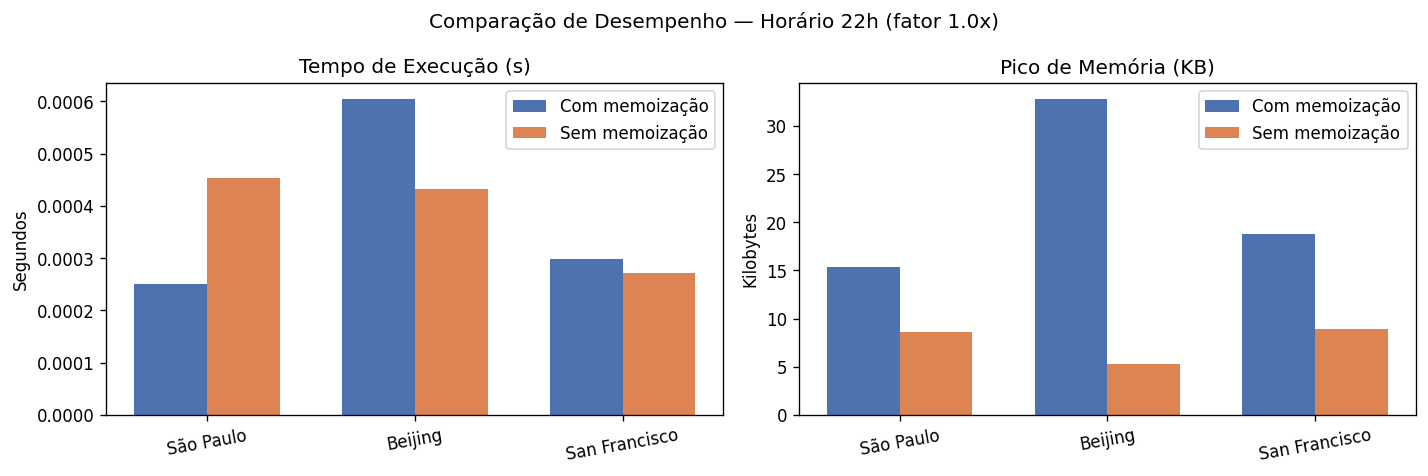

Gráfico salvo como desempenho.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cidades_nomes = list(df.index)
x = range(len(cidades_nomes))
w = 0.35

ax = axes[0]
ax.bar([i - w/2 for i in x], df["Tempo c/ Memo (s)"], width=w, label="Com memoização", color="#4C72B0")
ax.bar([i + w/2 for i in x], df["Tempo s/ Memo (s)"], width=w, label="Sem memoização", color="#DD8452")
ax.set_title("Tempo de Execução (s)")
ax.set_xticks(list(x))
ax.set_xticklabels(cidades_nomes, rotation=10)
ax.legend()
ax.set_ylabel("Segundos")

ax = axes[1]
ax.bar([i - w/2 for i in x], df["Mem c/ Memo (KB)"], width=w, label="Com memoização", color="#4C72B0")
ax.bar([i + w/2 for i in x], df["Mem s/ Memo (KB)"], width=w, label="Sem memoização", color="#DD8452")
ax.set_title("Pico de Memória (KB)")
ax.set_xticks(list(x))
ax.set_xticklabels(cidades_nomes, rotation=10)
ax.legend()
ax.set_ylabel("Kilobytes")

plt.suptitle(f"Comparação de Desempenho — Horário {hora_partida}h (fator {fator_horario(hora_partida)}x)", fontsize=12)
plt.tight_layout()
plt.savefig("desempenho.png", bbox_inches="tight")
plt.show()
print("Gráfico salvo como desempenho.png")


---
## Seção 5 — Visualização com Folium

Para cada cidade, exibimos:
- 🔵 Todas as estações (marcadores azuis)
- 🟠 Estações de integração (marcadores laranja)
- 🟢 Origem (verde) e 🔴 Destino (vermelho)
- **Linha azul escura** = menor caminho calculado pelo algoritmo
- **Linha cinza** = demais conexões do grafo


In [30]:
def gerar_mapa(grafo, coords, caminho_menor, estacoes_integracao,
               origem, destino, nome_cidade, zoom=12):
    centro = coords[origem]
    m = folium.Map(location=centro, zoom_start=zoom, tiles="CartoDB positron")

    visitadas_aresta = set()
    for est, vizinhos in grafo.items():
        for viz, _ in vizinhos:
            par = tuple(sorted([est, viz]))
            if par not in visitadas_aresta and est in coords and viz in coords:
                folium.PolyLine(
                    [coords[est], coords[viz]],
                    color="#999999", weight=2, opacity=0.5
                ).add_to(m)
                visitadas_aresta.add(par)

    if len(caminho_menor) >= 2:
        path_coords = [coords[e] for e in caminho_menor if e in coords]
        folium.PolyLine(
            path_coords, color="#1a3a8a", weight=5, opacity=0.9,
            tooltip=f"Menor caminho: {' → '.join(caminho_menor)}"
        ).add_to(m)

    for est, coord in coords.items():
        if est == origem:
            color, icon = "green", "play"
        elif est == destino:
            color, icon = "red", "stop"
        elif est in estacoes_integracao:
            color, icon = "orange", "transfer"
        else:
            color, icon = "blue", "train"

        folium.Marker(
            location=coord,
            tooltip=f"{'★ ' if est in estacoes_integracao else ''}{est}",
            icon=folium.Icon(color=color, icon="circle", prefix="fa")
        ).add_to(m)

    titulo = (
        f'<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);'
        f'z-index:1000;background:white;padding:8px 16px;border-radius:8px;'
        f'box-shadow:0 2px 6px rgba(0,0,0,.3);font-family:sans-serif;">'
        f'<b>{nome_cidade}</b> | {origem} → {destino}</div>'
    )
    m.get_root().html.add_child(folium.Element(titulo))
    return m


In [31]:

caminho_sp = resultados["São Paulo"]["caminho_menor"]
mapa_sp = gerar_mapa(
    grafo_sp, coords_sp, caminho_sp, estacoes_integracao_sp,
    "Tucuruvi", "Capão Redondo", "São Paulo — Metrô + CPTM", zoom=12
)
mapa_sp.save("mapa_saopaulo.html")
print(f"Rota SP: {' → '.join(caminho_sp)}")
mapa_sp


Rota SP: Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → São Bento → Sé → Ana Rosa → Santa Cruz → Hospital São Paulo → Santo Amaro → Capão Redondo


In [32]:

caminho_bj = resultados["Beijing"]["caminho_menor"]
mapa_bj = gerar_mapa(
    grafo_beijing, coords_beijing, caminho_bj, estacoes_integracao_bj,
    "Sihui East", "Xizhimen", "Beijing — Metrô", zoom=13
)
mapa_bj.save("mapa_beijing.html")
print(f"Rota Beijing: {' → '.join(caminho_bj)}")
mapa_bj


Rota Beijing: Sihui East → Guomao → Jianguomen → Chaoyangmen → Dongsi → Guloudajie → Xizhimen


In [33]:

caminho_sf = resultados["San Francisco"]["caminho_menor"]
mapa_sf = gerar_mapa(
    grafo_sf, coords_sf, caminho_sf, estacoes_integracao_sf,
    "Dublin/Pleasanton", "Daly City", "San Francisco — BART", zoom=11
)
mapa_sf.save("mapa_sanfrancisco.html")
print(f"Rota SF: {' → '.join(caminho_sf)}")
mapa_sf


Rota SF: Dublin/Pleasanton → West Dublin → Castro Valley → Bay Fair → Coliseum → Fruitvale → Lake Merritt → West Oakland → Embarcadero → Montgomery → Powell → Civic Center → 16th St → 24th St → Daly City


---
## Seção 6 — Análise de Complexidade

### Menor Caminho com Memoização

| Aspecto | Valor |
|---|---|
| Estados únicos possíveis | O(V × 2^V) — origem + subconjunto de visitados |
| Chamadas com cache | Cada estado calculado **uma única vez** |
| Complexidade efetiva | **O(V × 2^V)** no pior caso teórico |
| Complexidade prática | Muito inferior — grafos esparsos com poucos caminhos distintos |

Sem memoização, subproblemas são recalculados repetidamente → **O(2^n)** ou pior.

### Maior Caminho Simples (Backtracking)

| Aspecto | Valor |
|---|---|
| Complexidade | **O(V!)** no pior caso |
| Motivo | Explora todas as permutações possíveis de nós sem repetição |
| Otimização aplicada | `visitados.copy()` garante backtracking correto sem efeitos colaterais |

> O problema do maior caminho simples é **NP-difícil** em grafos gerais. O backtracking é a abordagem correta para grafos de tamanho moderado (como os nossas redes metroviárias).


---
## Seção 7 — Hipóteses e Conclusões

### Hipóteses adotadas
- Grafos **não-direcionados**: em metrôs o deslocamento é possível em ambos os sentidos com custo equivalente.
- Pesos das arestas representam **tempo médio em minutos** entre estações adjacentes.
- O fator de horário é aplicado **uniformemente** a todas as arestas — sem modelagem de congestionamento por trecho.
- Não modelamos falhas, atrasos ou filas em catracas.

### Conclusões sobre memoização

A memoização transformou o problema de busca de caminho mínimo de complexidade **exponencial** para **sub-exponencial**:

- Para grafos pequenos (como os nossos), o speedup absoluto pode ser modesto em tempo de relógio, mas o número de **chamadas recursivas eliminadas** é expressivo.
- O consumo de memória com cache é **ligeiramente maior** (armazenamos estados), mas perfeitamente viável.
- Para grafos maiores (redes reais com centenas de estações), o benefício seria **dramático** — sem memo, o sistema seria inviável.

### Conclusões sobre horários
- No horário de pico (17h–20h, fator 2.0×), o custo dos caminhos **dobra**, tornando alternativas fora do pico economicamente mais vantajosas.
- O bônus matinal (5h–7h, fator 0.6×) representa uma **redução de 40%** no custo efetivo.
